<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №6. Эпидемиологическая модель SIR

**Задача.** Промоделировать распространение эпидемии с помощью модели SIR
(Susceptible-Infected-Recovered):

`S' = -β*S*I`, `I' = β*S*I - γ*I`, `R' = γ*I`.

Нужно решить систему численно методом Эйлера на нормированных данных, перевести
результат в абсолютные числа заболевших, найти день пика эпидемии, максимальное
число одновременно заражённых и итоговое число переболевших.


In [ ]:
import pandas
import numpy as np
import scipy
import sympy
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
N = 763 # общая численность группы
#Начальные условия ( Нормированные данные )
I_0 = 1 / N # начальное количество заразившихся
S_0 = (N - I_0)/N # начальное колчество здоровых людей
R_0 = 0 # начальное количество выздоровевших

beta = 1.5
gamma = 0.5

In [ ]:
# Параметры дискретизации
t_0 = 0
t_max = 60 # дней
delta_t = 0.3 # шаг по времени

# Численное интегрирование (метод Эйлера)
def solve(S_0, I_0, R_0, steps, delta_T):
  T = np.zeros(steps + 1)
  S = np.zeros(steps + 1)
  I = np.zeros(steps + 1)
  R = np.zeros(steps + 1)

  T[0] = t_0
  S[0] = S_0
  I[0] = I_0
  R[0] = R_0

  for n in range(steps):
    T[n + 1] = T[n] + delta_T
    dS = - beta * S[n] * I[n] * delta_t
    dI = (beta * S[n] * I[n] - gamma * I[n]) * delta_t
    dR = gamma * I[n] * delta_t

    S[n + 1] += S[n] + dS
    R[n + 1] += R[n] + dR
    I[n + 1] += I[n] + dI
    total = S[n + 1] + R[n + 1] + I[n + 1]
    S[n + 1] /= total
    R[n + 1] /= total
    I[n + 1] /= total
  return T, S, I, R

steps = int(t_max / delta_t)
T, S, I, R = solve(S_0, I_0, R_0, steps, delta_t)


In [ ]:
#Перевод в абсолютные числа
S_abs = S * N
R_abs = R * N
I_abs = I * N

In [ ]:
print(f"Проверка: S + I + R = {S_abs[-1] + R_abs[-1] + I_abs[-1]:.2f} (должно быть {N}) ")
print(f"Пик эпидемии: день {T[np.argmax(I)]:.1f}, максимум зараженных: {np.max(I_abs):.0f} чел.")
print(f"Всего переболело: {R_abs[-1]:.0f} человек")

Проверка: S + I + R = 763.00 (должно быть 763) 
Пик эпидемии: день 8.1, максимум зараженных: 244 чел.
Всего переболело: 725 человек


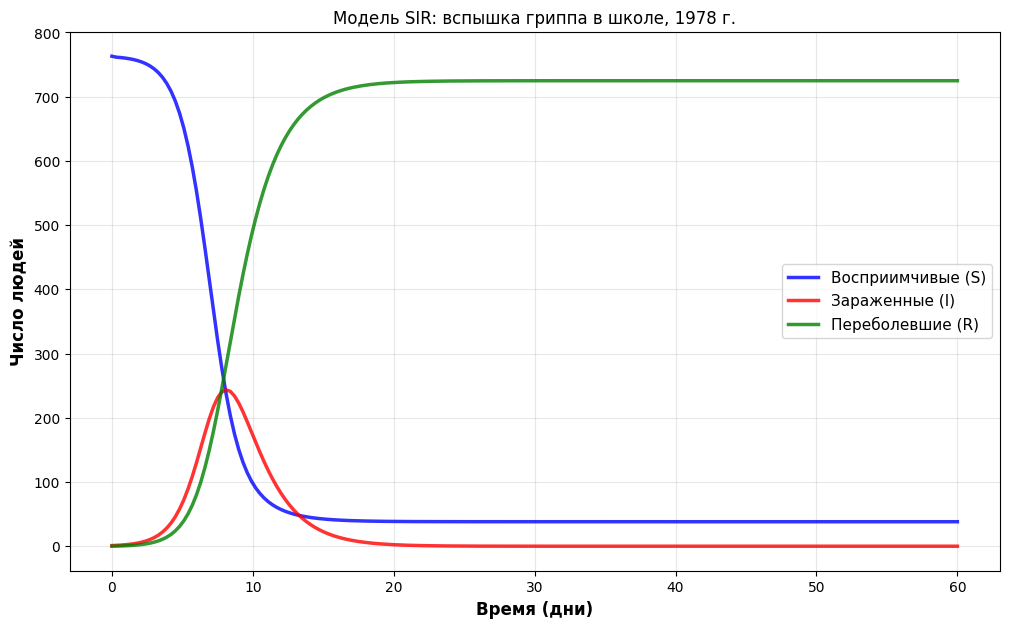

In [ ]:
# Построение графиков
plt.figure(figsize=(12, 7))
plt.plot(T, S_abs, 'b-', linewidth=2.5, label="Восприимчивые (S)", alpha=0.8)
plt.plot(T, I_abs, 'r-', linewidth=2.5, label="Зараженные (I)", alpha=0.8)
plt.plot(T, R_abs, 'g-', linewidth=2.5, label="Переболевшие (R)", alpha=0.8)

plt.xlabel('Время (дни)', fontsize=12, fontweight='bold')
plt.ylabel('Число людей', fontsize=12, fontweight='bold')
plt.title('Модель SIR: вспышка гриппа в школе, 1978 г.')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()